# Factors Influencing the Success of Games on Steam
**Name:** Yiran Wang  
**ID:** 2472517

## 1. Project Overview

This notebook investigates which factors are associated with the success of games on Steam.  
It focuses on three dimensions: price, genre, and player reviews.  
Success is measured using review-based proxies: total review count and positive review ratio.

The purpose of this analysis is to provide historical, data-driven insights for users such as indie developers, publishers, and game investors.

## 2. Target Users and Business Value

### Target Users
- Game developers
- Game publishers
- Game industry investors

### Business Value
This analysis can help users make more informed decisions based on historical platform patterns:

- **Developers** may use it to think about pricing, genre positioning, and audience response.
- **Publishers** may use it to compare categories of games and evaluate market positioning.
- **Investors** may use it to understand which game characteristics have historically been associated with stronger attention and more positive reception.

This notebook does not predict future success. Instead, it provides historical association-based evidence that may support decision-making.

## 3. Research Questions

This notebook addresses the following questions:

1. Is game price associated with popularity and player satisfaction?
2. Do different genres show different patterns of success?
3. Is player reception associated with game popularity?

## 4. Data Source
The full dataset is not included in this repository because the file is too large to upload conveniently to GitHub.

A small sample dataset is included for preview and testing.

- Original source: https://www.kaggle.com/datasets/artermiloff/steam-games-dataset
- Access date: 24 April 2026
- Key variables used: `name`, `price`, `genres`, `release_date`, `positive`, `negative`

The full dataset file used in this analysis is `games_march2025_full.csv`.
Due to file size limits, it is not included in this GitHub repository.

A small sample file, `steam_sample.csv`, is included for preview and limited testing only.

To reproduce the full analysis, download `games_march2025_full.csv` from the source link above and upload it to the Jupyter Notebook **Files** section.
Make sure it is placed in the same working directory as this notebook before running all cells.

# 5. Variables and Success Definition
## Variables used
- name: Game title
- release_date: Release date
- price: Game price (USD)
- genres: Game genre
- positive: Number of positive reviews
- negative: Number of negative reviews

## Success Definition
- Primary: review_count = positive + negative (measures popularity/attention)
- Secondary: positive_ratio = positive / review_count (measures player satisfaction)

These are proxies for success, not direct financial metrics.

## 6. Data Loading and Initial Inspection

This notebook is designed to run from top to bottom.  
All package imports appear first, followed by data loading, cleaning, feature engineering, analysis, and interpretation.

Please place the dataset file in the correct folder before running the notebook.

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ast

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

df = pd.read_csv("games_march2025_full.csv")

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())
print("\nFirst 5 rows:")
print(df[['name', 'price', 'positive', 'negative', 'genres']].head())

Dataset shape: (94948, 47)

Columns:
['appid', 'name', 'release_date', 'required_age', 'price', 'dlc_count', 'detailed_description', 'about_the_game', 'short_description', 'reviews', 'header_image', 'website', 'support_url', 'support_email', 'windows', 'mac', 'linux', 'metacritic_score', 'metacritic_url', 'achievements', 'recommendations', 'notes', 'supported_languages', 'full_audio_languages', 'packages', 'developers', 'publishers', 'categories', 'genres', 'screenshots', 'movies', 'user_score', 'score_rank', 'positive', 'negative', 'estimated_owners', 'average_playtime_forever', 'average_playtime_2weeks', 'median_playtime_forever', 'median_playtime_2weeks', 'discount', 'peak_ccu', 'tags', 'pct_pos_total', 'num_reviews_total', 'pct_pos_recent', 'num_reviews_recent']

First 5 rows:
                              name  price  positive  negative  \
0                 Counter-Strike 2   0.00   7480813   1135108   
1              PUBG: BATTLEGROUNDS   0.00   1487960   1024436   
2            

# 7. Data Cleaning and Preparation

In [16]:
# Keep only needed columns
df = df[['name', 'price', 'positive', 'negative', 'genres']].copy()

# Remove duplicates
df = df.drop_duplicates()

# Convert data types
df['price'] = pd.to_numeric(df['price'], errors='coerce')
df['positive'] = pd.to_numeric(df['positive'], errors='coerce')
df['negative'] = pd.to_numeric(df['negative'], errors='coerce')

# Drop rows with missing critical values
df = df.dropna(subset=['price','positive','negative','genres'])

# Remove games with zero reviews
# Explanation:
# Games with zero total reviews are removed because the analysis uses review-based success proxies,
# and positive ratio cannot be meaningfully calculated when total reviews equal zero.
df = df[(df['positive'] + df['negative']) > 0]

# Remove extreme price outliers
# Explanation:
# Extreme price outliers above the 99th percentile are excluded to reduce distortion in grouped
# summaries and visualisations. This step improves interpretability rather than manipulating results.
df = df[df['price'] <= df['price'].quantile(0.99)]

print("Cleaned dataset shape:", df.shape)

Cleaned dataset shape: (72146, 5)


## 8. Feature Engineering

In [17]:
# Success metrics
df['review_count'] = df['positive'] + df['negative']
df['positive_ratio'] = df['positive'] / df['review_count']

# Price bands
def price_band(price):
    if price == 0:
        return 'Free ($0.00)'
    elif price <= 19.99:
        return 'Low ($0.01–19.99)'
    elif price <= 39.99:
        return 'Mid ($20.00–39.99)'
    else:
        return 'High ($40.00+)'

df['price_band'] = df['price'].apply(price_band)

df['genres_parsed'] = df['genres'].apply(ast.literal_eval)

# Extract main genre
# Explanation:
# Many Steam games belong to multiple genres. To keep analysis simple and avoid double counting,
# only the first listed genre is used as the main genre. This simplifies interpretation.
def extract_main_genre(genre_list):
    if isinstance(genre_list, list) and len(genre_list) > 0:
        return genre_list[0]
    else:
        return "Unknown"

df['main_genre'] = df['genres_parsed'].apply(extract_main_genre)

# Keep top 12 most frequent genres
top_genres = df['main_genre'].value_counts().head(12).index
df = df[df['main_genre'].isin(top_genres)]

## 9. Exploratory Analysis

Review count is highly right-skewed, because a small number of blockbuster titles receive very large numbers of reviews.

For this reason, grouped comparisons in this notebook use **median review count** rather than mean review count, since median better reflects the typical game and is less influenced by extreme values.

Positive ratio remains suitable for mean comparison because it is a bounded proportion.

- Summary Statistics

In [18]:
print(df[['price', 'review_count', 'positive_ratio']].describe())

              price  review_count  positive_ratio
count  71154.000000  7.115400e+04    71154.000000
mean       7.310328  1.718871e+03        0.755505
std        7.640992  4.071925e+04        0.240128
min        0.000000  1.000000e+00        0.000000
25%        1.990000  6.000000e+00        0.642857
50%        4.990000  2.400000e+01        0.815789
75%        9.990000  1.250000e+02        0.942488
max       49.990000  8.615921e+06        1.000000


- Price distribution

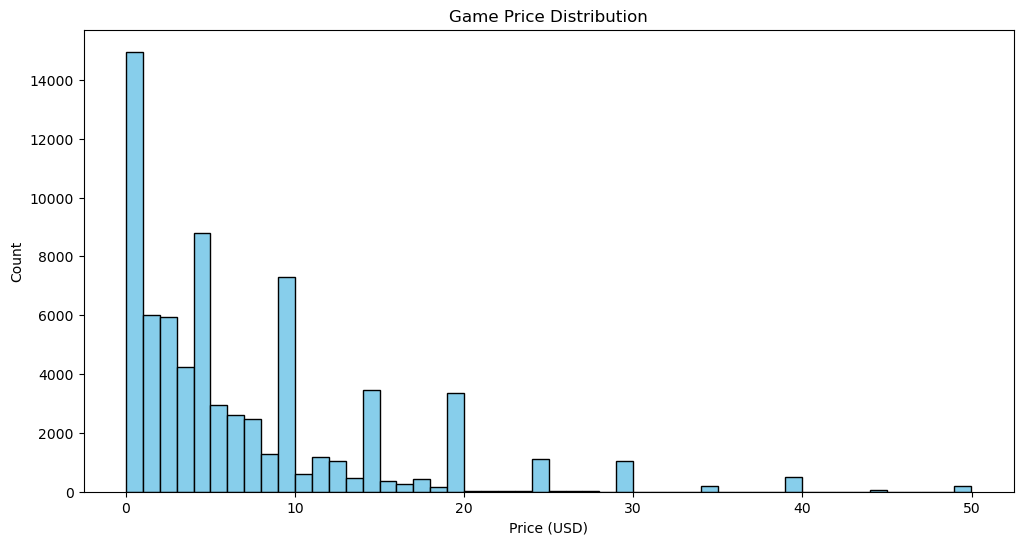

In [19]:
plt.hist(df['price'], bins=50, color='skyblue', edgecolor='black')
plt.title('Game Price Distribution')
plt.xlabel('Price (USD)')
plt.ylabel('Count')
plt.show()

**Interpretation**:
This histogram shows the overall distribution of game prices on Steam. Most games are clustered at lower price points, which helps explain the structure of later price-band analysis.

- Genre count

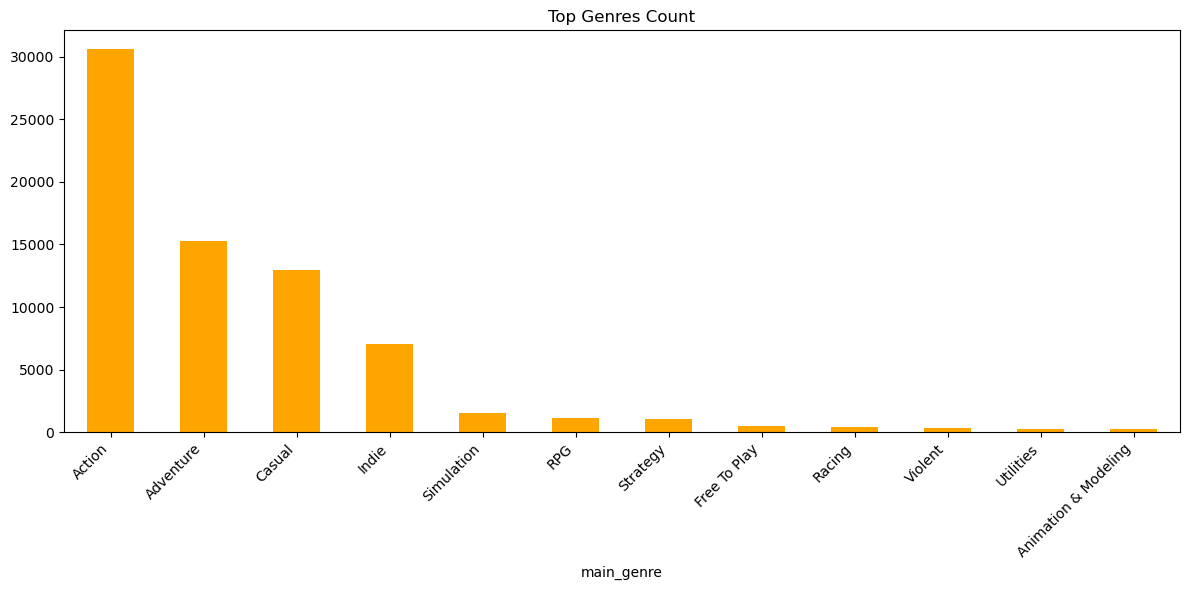

In [20]:
df['main_genre'].value_counts().plot(kind='bar', color='orange')
plt.title('Top Genres Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Interpretation**:
This chart shows the most frequent game genres in the dataset. Indie and Action games dominate the platform, which provides context for genre performance analysis.

# 10. Price and Success

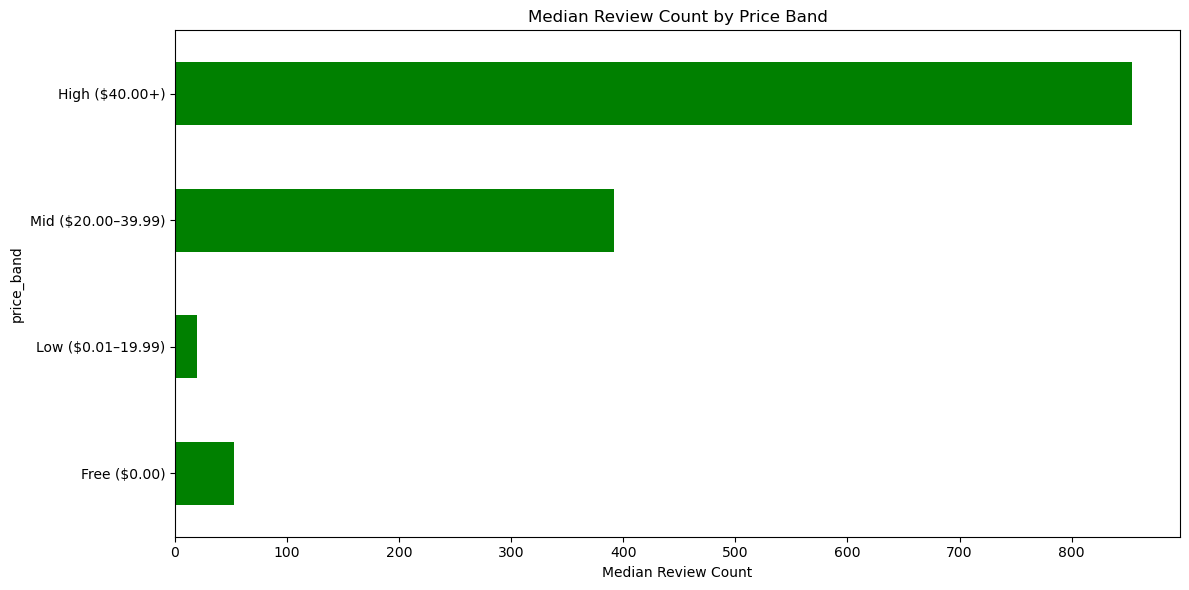

In [21]:
price_order = [
    'Free ($0.00)',
    'Low ($0.01–19.99)',
    'Mid ($20.00–39.99)',
    'High ($40.00+)'
]

price_review = df.groupby('price_band')['review_count'].median().reindex(price_order)
price_ratio = df.groupby('price_band')['positive_ratio'].mean().reindex(price_order)

price_review.plot(kind='barh', color='green')
plt.title('Median Review Count by Price Band')
plt.xlabel('Median Review Count')
plt.tight_layout()
plt.show()

**Interpretation**:
High-priced games have the highest median review count, indicating stronger typical popularity. Low-priced games show the lowest engagement. This directly answers the first research question about price and success.

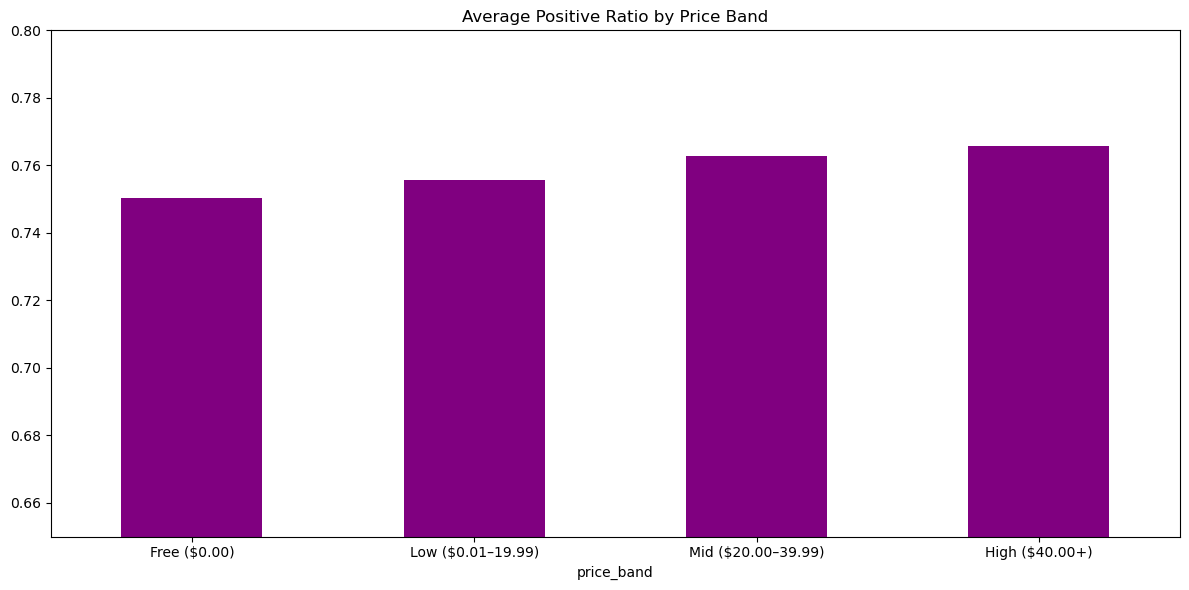

In [22]:
price_ratio.plot(kind='bar', color='purple')
plt.title('Average Positive Ratio by Price Band')
plt.ylim(0.65, 0.8)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Interpretation**:
Higher-priced games also achieve better average player satisfaction. Free games show the lowest positive ratio. This suggests premium pricing correlates with both player attention and perceived quality.

# 11. Genre and Success

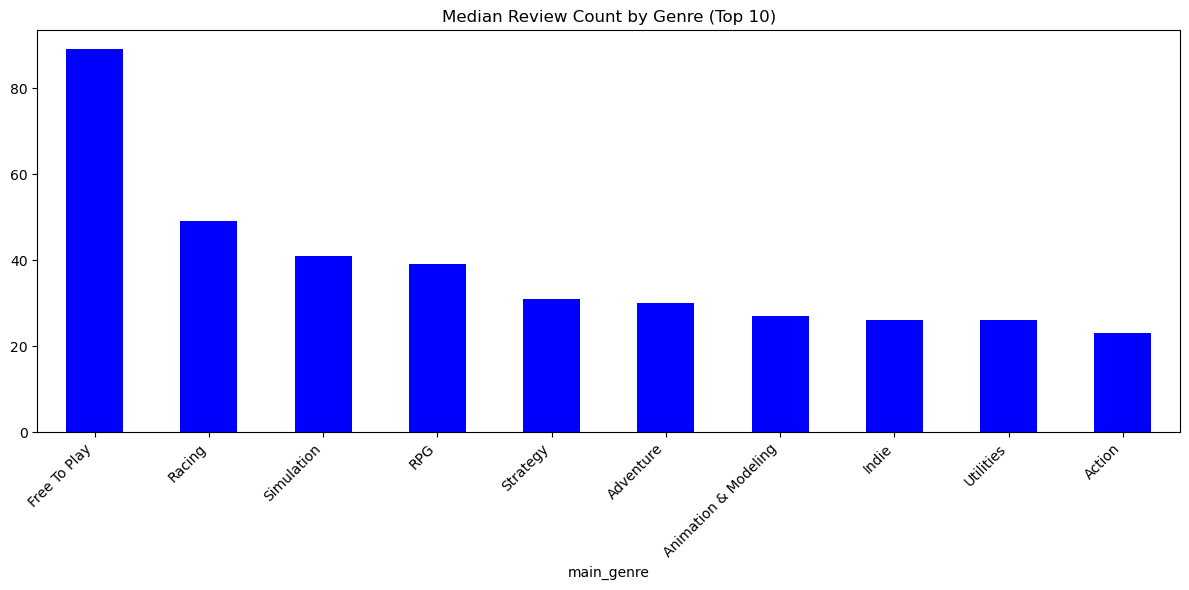

In [23]:
genre_review = df.groupby('main_genre')['review_count'].median().sort_values(ascending=False).head(10)
genre_ratio = df.groupby('main_genre')['positive_ratio'].mean().sort_values(ascending=False).head(10)

genre_review.plot(kind='bar', color='blue')
plt.title('Median Review Count by Genre (Top 10)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Interpretation**:
Game popularity varies significantly across different game genres.

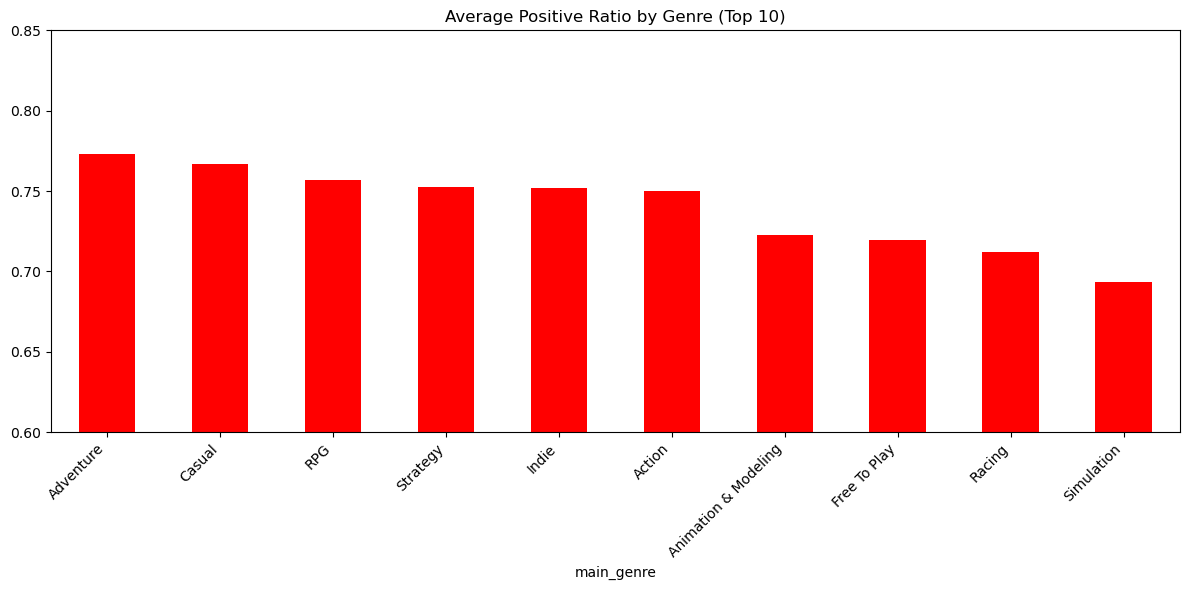

In [25]:
genre_ratio.plot(kind='bar', color='red')
plt.title('Average Positive Ratio by Genre (Top 10)')
plt.ylim(0.6, 0.85)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Interpretation**:
Genre also affects player satisfaction. Some genres maintain consistently high ratings, helping publishers prioritize genres with both popularity and quality appeal.

# 12. Player Reception and Success

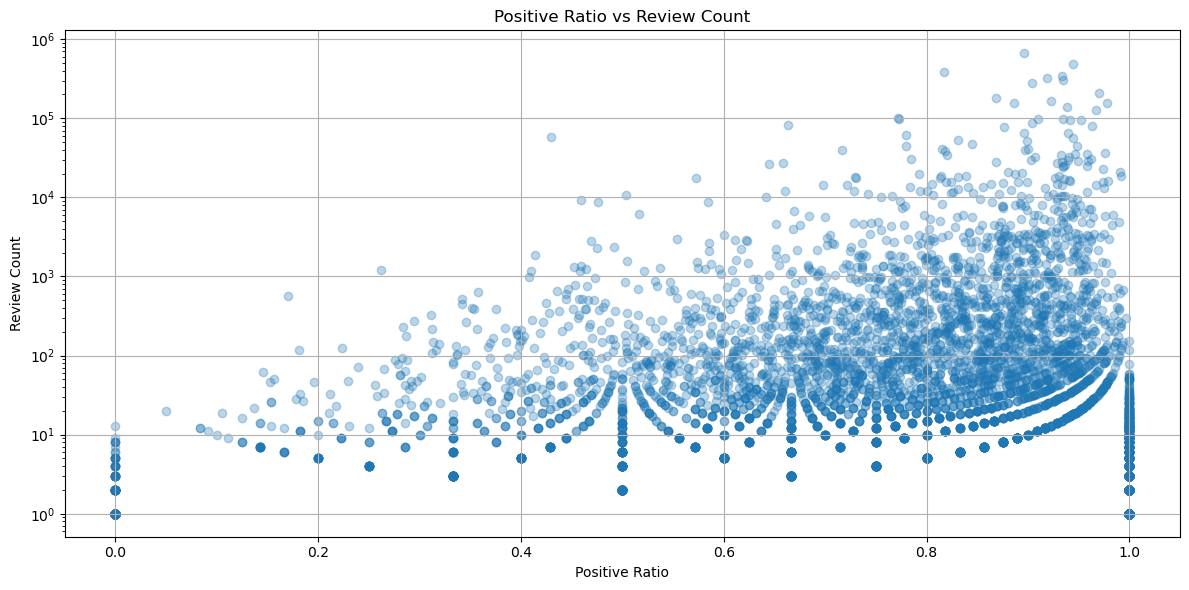

In [26]:
# Sample 5000 points to avoid overcrowding
sample = df.sample(6000, random_state=1)

plt.scatter(sample['positive_ratio'], sample['review_count'], alpha=0.3)
plt.title('Positive Ratio vs Review Count')
plt.xlabel('Positive Ratio')
plt.ylabel('Review Count')
plt.yscale('log')
plt.grid(True)
plt.tight_layout()
plt.show()

**Interpretation**:
There is a moderate positive relationship between positive ratio and review count. Games with better reception tend to attract more attention, though the relationship is not definitive.

# 13. Key Findings
- Price has a clear association with typical game popularity and positive review rate.  
  High-priced games tend to have higher popularity and positive review rates, followed by mid-priced games.
- game genres also affect a game’s success, and catering to players’ preferences is very important.
- There is a moderate positive correlation between a game’s positive review rate and its review count.

# 14. Limitations
- This approach simplifies multi-genre titles and brings limitations to the final results.
- The analysis shows correlation, not causation.
- Review-based metrics are proxies and do not directly represent revenue or profit. Meanwhile, external factors such as marketing are not taken into account.
- Results reflect historical patterns and may not perfectly predict future performance.

# 15. Conclusion

This notebook shows that price, genre, and player reception are all associated with different dimensions of game success on Steam.  
Among these, player attention and satisfaction appear to vary substantially across groups, although the results should be interpreted as historical associations rather than causal rules.

For game developers, publishers, and investors, the findings may serve as a useful exploratory reference when thinking about pricing, positioning, release strategy, and audience response.